# 06. 처리시간 및 대기시간 분석

접수→배차, 배차→승차, 접수→승차, 접수→취소 시간을 계산해 시간대/요일/지역별 운영 병목을 확인한다.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data'

request_path = DATA_DIR / '서울시설공단_장애인콜택시 접수일시_월주차_파생컬럼_20251231.csv'
print(request_path)

usecols = [
    '접수일시', '배차일시', '승차일시', '취소일시',
    '출발구', '접수요일', '접수시간대'
]

df_wait = pd.read_csv(request_path, usecols=usecols)

for col in ['접수일시', '배차일시', '승차일시', '취소일시']:
    df_wait[col] = pd.to_datetime(df_wait[col], errors='coerce')

before_rows = len(df_wait)
df_wait = df_wait[
    (df_wait['접수일시'] >= '2025-01-01') &
    (df_wait['접수일시'] < '2026-01-01')
].copy()

print(f'원본 행 수: {before_rows:,}')
print(f'2025년 분석 행 수: {len(df_wait):,}')
for col in ['접수일시', '배차일시', '승차일시', '취소일시']:
    print(f'{col} 결측/변환실패: {df_wait[col].isna().sum():,}건')

df_wait.head()


/Users/blaumonde/final-example/data/서울시설공단_장애인콜택시 접수일시_월주차_파생컬럼_20251231.csv
원본 행 수: 1,729,476
2025년 분석 행 수: 1,729,415
접수일시 결측/변환실패: 0건
배차일시 결측/변환실패: 177,578건
승차일시 결측/변환실패: 246,036건
취소일시 결측/변환실패: 1,484,102건


,접수일시,배차일시,승차일시,취소일시,출발구,접수시간대,접수요일
0,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,NaT,용산구,0,수요일
1,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaT,2025-01-01 00:21:15,영등포구,0,수요일
2,2025-01-01 00:03:31.230,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,NaT,노원구,0,수요일
3,2025-01-01 00:03:40.573,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,NaT,영등포구,0,수요일
4,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,NaT,송파구,0,수요일


## 처리시간 파생 컬럼 생성


In [10]:
df_wait['취소여부'] = df_wait['취소일시'].notna()
df_wait['탑승여부'] = df_wait['승차일시'].notna()
df_wait['접수시간대_label'] = df_wait['접수시간대'].map(
    lambda x: f'{int(x):02d}시' if pd.notna(x) else pd.NA
)

df_wait['접수_배차_분'] = (df_wait['배차일시'] - df_wait['접수일시']).dt.total_seconds() / 60
df_wait['배차_승차_분'] = (df_wait['승차일시'] - df_wait['배차일시']).dt.total_seconds() / 60
df_wait['접수_승차_분'] = (df_wait['승차일시'] - df_wait['접수일시']).dt.total_seconds() / 60
df_wait['접수_취소_분'] = (df_wait['취소일시'] - df_wait['접수일시']).dt.total_seconds() / 60

processing_cols = ['접수_배차_분', '배차_승차_분', '접수_승차_분', '접수_취소_분']
invalid_processing_time = df_wait[
    df_wait[processing_cols].lt(0).any(axis=1)
][['접수일시', '배차일시', '승차일시', '취소일시'] + processing_cols]

print(f'음수 처리시간 행 수: {len(invalid_processing_time):,}')
display(invalid_processing_time.head(20))

df_wait_valid = df_wait.copy()
for col in processing_cols:
    df_wait_valid.loc[df_wait_valid[col] < 0, col] = pd.NA

df_wait_valid[processing_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99])


음수 처리시간 행 수: 7


,접수일시,배차일시,승차일시,취소일시,접수_배차_분,배차_승차_분,접수_승차_분,접수_취소_분
107,2025-01-01 04:45:00.737,NaT,NaT,2024-01-01 09:00:00,NaN,NaN,NaN,-526785.012283
200,2025-01-01 08:34:51.000,2025-01-01 08:30:00,2025-01-01 09:50:00,NaT,-4.85,80.0,75.15,NaN
887622,2025-07-11 19:11:53.000,NaT,NaT,2025-07-11 17:51:05,NaN,NaN,NaN,-80.800000
887818,2025-07-12 00:42:14.643,NaT,NaT,2025-07-11 17:47:15,NaN,NaN,NaN,-414.994050
887819,2025-07-12 00:51:30.000,NaT,NaT,2025-07-11 17:50:36,NaN,NaN,NaN,-420.900000
887826,2025-07-11 23:55:00.383,NaT,NaT,2025-07-11 17:50:46,NaN,NaN,NaN,-364.239717
887838,2025-07-12 03:10:36.950,NaT,NaT,2025-07-11 18:16:17,NaN,NaN,NaN,-534.332500


,접수_배차_분,배차_승차_분,접수_승차_분,접수_취소_분
count,1.551836e+06,1.483379e+06,1.483379e+06,245307.000000
mean,8.957220e+01,1.855265e+01,1.096652e+02,64.273704
std,2.902979e+02,8.307278e+00,2.945768e+02,206.352594
min,1.684500e-01,4.611667e-02,2.980000e-01,0.033333
50%,1.263028e+01,1.755817e+01,3.382800e+01,15.177617
90%,1.096317e+02,2.911791e+01,1.336272e+02,105.925190
95%,1.660611e+02,3.317134e+01,1.957082e+02,146.003118
99%,1.447745e+03,4.282836e+01,1.469551e+03,1398.565826
max,2.166574e+03,2.493893e+02,2.244264e+03,2130.516667


## 전체 처리시간 요약


In [3]:
def summarize_minutes(series):
    return pd.Series({
        '건수': series.notna().sum(),
        '평균(분)': series.mean(),
        '중앙값(분)': series.median(),
        '상위90%(분)': series.quantile(0.9),
        '상위95%(분)': series.quantile(0.95),
        '최대(분)': series.max(),
    })

processing_time_summary = pd.DataFrame({
    '접수→배차': summarize_minutes(df_wait_valid['접수_배차_분']),
    '배차→승차': summarize_minutes(df_wait_valid['배차_승차_분']),
    '접수→승차': summarize_minutes(df_wait_valid['접수_승차_분']),
    '접수→취소': summarize_minutes(df_wait_valid['접수_취소_분']),
}).T.reset_index(names='구간')

display(processing_time_summary)


,구간,건수,평균(분),중앙값(분),상위90%(분),상위95%(분),최대(분)
0,접수→배차,1551836.0,89.572201,12.630275,109.631692,166.061104,2166.573950
1,배차→승차,1483379.0,18.552651,17.558167,29.117910,33.171338,249.389333
2,접수→승차,1483379.0,109.665178,33.828000,133.627227,195.708157,2244.263550
3,접수→취소,245307.0,64.273704,15.177617,105.925190,146.003118,2130.516667


## 시간대별 처리시간


,접수시간대,접수시간대_label,접수건수,탑승건수,평균_접수배차분,중앙값_접수배차분,p90_접수배차분,평균_배차승차분,중앙값_배차승차분,p90_배차승차분,평균_접수승차분,중앙값_접수승차분,p90_접수승차분
0,0,00시,2207,1702,20.583190,12.581058,49.613167,23.906737,23.566917,36.452578,44.591428,39.572167,75.271107
1,1,01시,1342,1037,25.940227,11.817833,80.036177,23.393256,22.864383,36.510417,49.205054,39.455667,107.421763
2,2,02시,2902,2604,68.927093,97.575000,111.966892,23.389810,22.673083,36.370213,92.494686,119.636392,142.338997
3,3,03시,6680,5788,105.381406,126.270842,187.899928,22.802382,21.712700,35.493518,127.238870,146.335858,207.350800
4,4,04시,20351,16157,116.343277,134.327167,164.389442,20.528912,19.372233,31.664893,136.185019,155.426617,186.808443
5,5,05시,23036,16798,101.825715,127.216692,155.232517,21.046486,20.162467,32.061583,121.422263,143.551108,178.406315
6,6,06시,29433,23560,64.900107,49.311167,138.730533,19.946268,18.959892,30.157900,84.377262,68.624608,161.460382
7,7,07시,124043,104359,336.194497,45.995217,1446.321300,20.027272,19.156667,30.062647,366.935080,67.221217,1464.897083
8,8,08시,144174,123324,284.682998,44.831408,1442.543933,19.495607,18.758108,29.066833,311.084245,64.576475,1460.547517
9,9,09시,111801,94984,44.508115,20.298700,74.362100,18.951095,18.209783,28.912687,63.446299,40.235417,95.835150


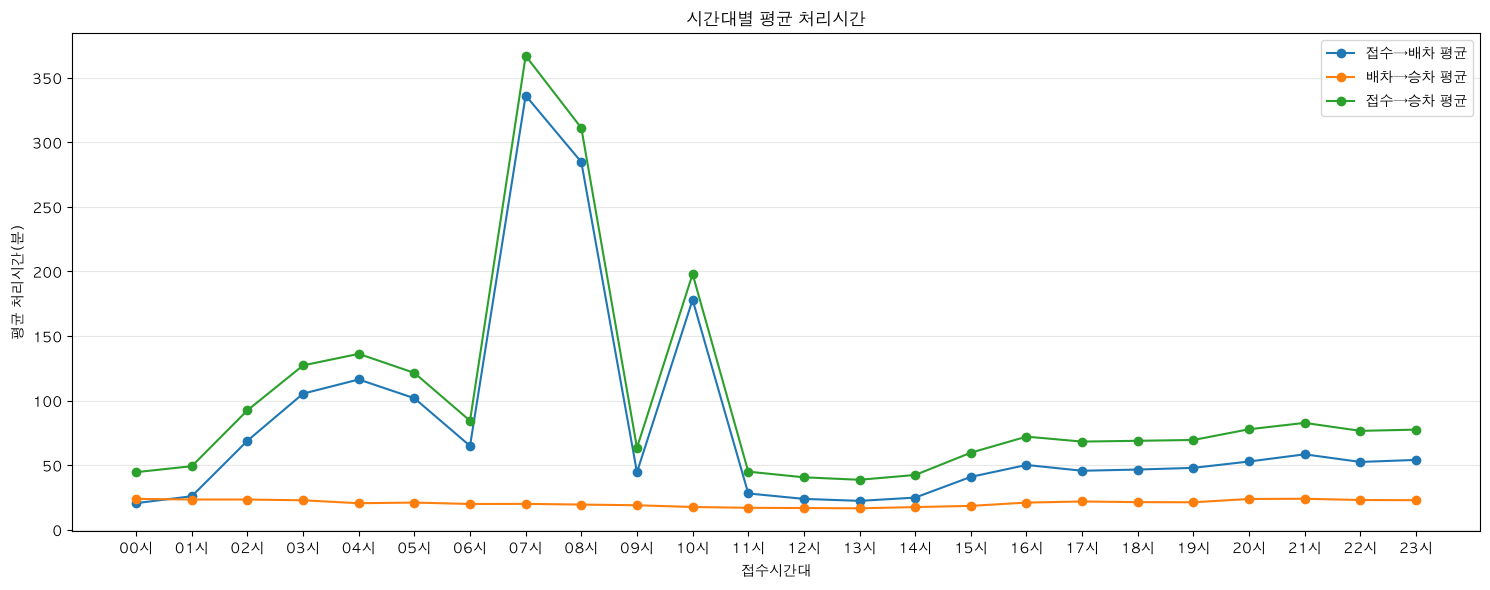

In [4]:
time_wait_summary = (
    df_wait_valid
    .dropna(subset=['접수시간대'])
    .groupby(['접수시간대', '접수시간대_label'])
    .agg(
        접수건수=('접수일시', 'size'),
        탑승건수=('탑승여부', 'sum'),
        평균_접수배차분=('접수_배차_분', 'mean'),
        중앙값_접수배차분=('접수_배차_분', 'median'),
        p90_접수배차분=('접수_배차_분', lambda s: s.quantile(0.9)),
        평균_배차승차분=('배차_승차_분', 'mean'),
        중앙값_배차승차분=('배차_승차_분', 'median'),
        p90_배차승차분=('배차_승차_분', lambda s: s.quantile(0.9)),
        평균_접수승차분=('접수_승차_분', 'mean'),
        중앙값_접수승차분=('접수_승차_분', 'median'),
        p90_접수승차분=('접수_승차_분', lambda s: s.quantile(0.9)),
    )
    .reset_index()
    .sort_values('접수시간대')
)

display(time_wait_summary)

plt.figure(figsize=(15, 6))
plt.plot(time_wait_summary['접수시간대_label'], time_wait_summary['평균_접수배차분'], marker='o', label='접수→배차 평균')
plt.plot(time_wait_summary['접수시간대_label'], time_wait_summary['평균_배차승차분'], marker='o', label='배차→승차 평균')
plt.plot(time_wait_summary['접수시간대_label'], time_wait_summary['평균_접수승차분'], marker='o', label='접수→승차 평균')
plt.title('시간대별 평균 처리시간')
plt.xlabel('접수시간대')
plt.ylabel('평균 처리시간(분)')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 요일 X 시간대별 평균 접수→승차 시간


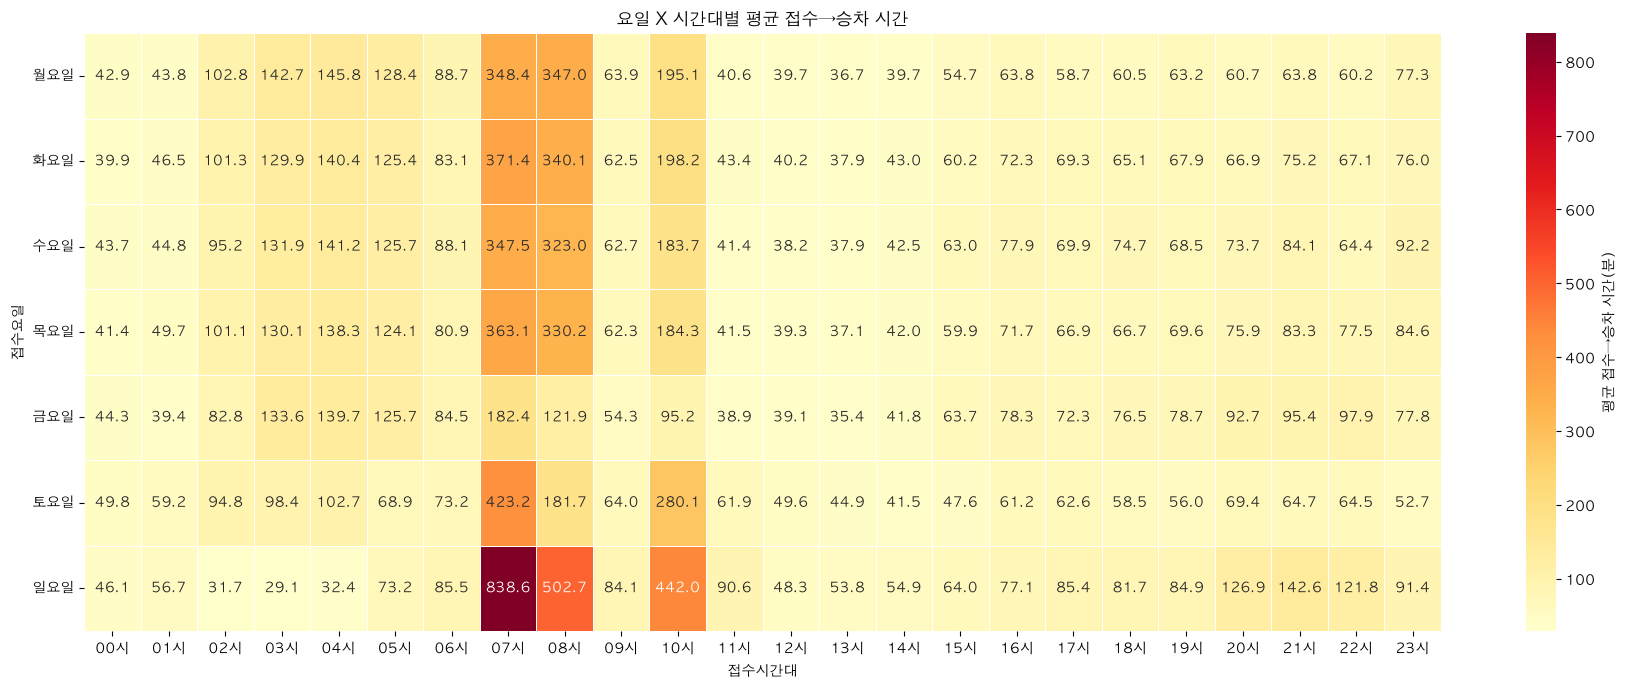

접수시간대_label,00시,01시,02시,03시,04시,05시,06시,07시,08시,09시,...,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
접수요일,,,,,,,,,,,,,,,,,,,,,
월요일,42.914761,43.835605,102.784138,142.735528,145.833530,128.406416,88.717792,348.380887,347.002226,63.894270,...,39.665457,54.672659,63.826956,58.711363,60.474331,63.235348,60.664957,63.837986,60.210881,77.283047
화요일,39.912073,46.504515,101.330324,129.861589,140.374948,125.409430,83.125597,371.420406,340.075557,62.520748,...,43.012788,60.169382,72.345858,69.336588,65.140300,67.900015,66.948677,75.173846,67.074383,76.042257
수요일,43.659951,44.825545,95.196177,131.930018,141.161278,125.745677,88.144947,347.526043,322.977647,62.741251,...,42.478022,62.983890,77.946693,69.949512,74.742778,68.494090,73.709155,84.095025,64.438508,92.207027
목요일,41.418970,49.681654,101.079559,130.095711,138.260378,124.085481,80.862250,363.078605,330.223786,62.280160,...,41.965417,59.868562,71.747402,66.904879,66.700644,69.566444,75.911898,83.333104,77.522056,84.632873
금요일,44.259749,39.420313,82.775334,133.618764,139.692686,125.652196,84.517951,182.412670,121.884033,54.339443,...,41.817043,63.654715,78.271945,72.343810,76.456093,78.745070,92.659676,95.418892,97.888011,77.784577
토요일,49.752215,59.231600,94.773568,98.368870,102.734216,68.921176,73.240193,423.231368,181.707698,64.011769,...,41.481543,47.607834,61.206512,62.629558,58.531388,55.958130,69.402193,64.722576,64.515700,52.651606
일요일,46.066670,56.739055,31.696923,29.098689,32.408215,73.168555,85.513565,838.558148,502.748148,84.113079,...,54.851532,64.004421,77.059204,85.376336,81.726942,84.937081,126.914150,142.647473,121.772851,91.428103


In [5]:
weekday_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']

weekday_hour_wait_pivot = (
    df_wait_valid
    .dropna(subset=['접수요일', '접수시간대_label', '접수_승차_분'])
    .pivot_table(
        index='접수요일',
        columns='접수시간대_label',
        values='접수_승차_분',
        aggfunc='mean'
    )
    .reindex(weekday_order)
)
weekday_hour_wait_pivot = weekday_hour_wait_pivot[[f'{hour:02d}시' for hour in range(24) if f'{hour:02d}시' in weekday_hour_wait_pivot.columns]]

plt.figure(figsize=(18, 7))
sns.heatmap(
    weekday_hour_wait_pivot,
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.4,
    cbar_kws={'label': '평균 접수→승차 시간(분)'}
)
plt.title('요일 X 시간대별 평균 접수→승차 시간')
plt.xlabel('접수시간대')
plt.ylabel('접수요일')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

weekday_hour_wait_pivot


## 지역별 운영 병목 후보


,출발구,접수건수,탑승건수,취소건수,평균_접수승차분,중앙값_접수승차분,p90_접수승차분,취소율(%),탑승전환율(%)
0,노원구,176744,159067,17588,100.155495,25.537933,92.092267,9.951116,89.998529
1,강서구,116499,100377,16070,130.502122,31.230333,134.787690,13.794110,86.161255
2,강동구,102476,90111,12324,94.597716,30.246833,112.261833,12.026231,87.933760
3,서대문구,96270,83576,12661,94.150162,34.580417,135.911475,13.151553,86.814168
4,은평구,95128,79925,15159,94.767802,33.578117,98.295040,15.935371,84.018375
5,마포구,94889,82105,12757,90.844402,32.479833,140.071053,13.444129,86.527416
6,송파구,72214,61361,10819,126.065314,35.911833,147.431617,14.981859,84.971058
7,영등포구,72015,61465,10511,88.012913,37.531333,129.370627,14.595570,85.350274
8,강남구,70060,56127,13910,127.221913,40.927717,147.728113,19.854411,80.112760
9,중랑구,67990,60663,7310,110.259364,28.487617,94.099700,10.751581,89.223415


,출발구,접수건수,탑승건수,취소건수,평균_접수승차분,중앙값_접수승차분,p90_접수승차분,취소율(%),탑승전환율(%)
0,양천구,63791,56098,7659,143.171698,33.438258,152.122872,12.006396,87.940305
1,구로구,61894,53197,8658,143.121160,37.753900,147.374593,13.988432,85.948557
2,강서구,116499,100377,16070,130.502122,31.230333,134.787690,13.794110,86.161255
3,강남구,70060,56127,13910,127.221913,40.927717,147.728113,19.854411,80.112760
4,송파구,72214,61361,10819,126.065314,35.911833,147.431617,14.981859,84.971058
5,성북구,58047,49579,8448,122.672987,37.224950,155.088993,14.553724,85.411821
6,동대문구,64170,56639,7501,115.139427,32.906050,118.513540,11.689263,88.263986
7,관악구,62164,52010,10131,110.892172,40.671833,146.853200,16.297214,83.665787
8,중랑구,67990,60663,7310,110.259364,28.487617,94.099700,10.751581,89.223415
9,노원구,176744,159067,17588,100.155495,25.537933,92.092267,9.951116,89.998529


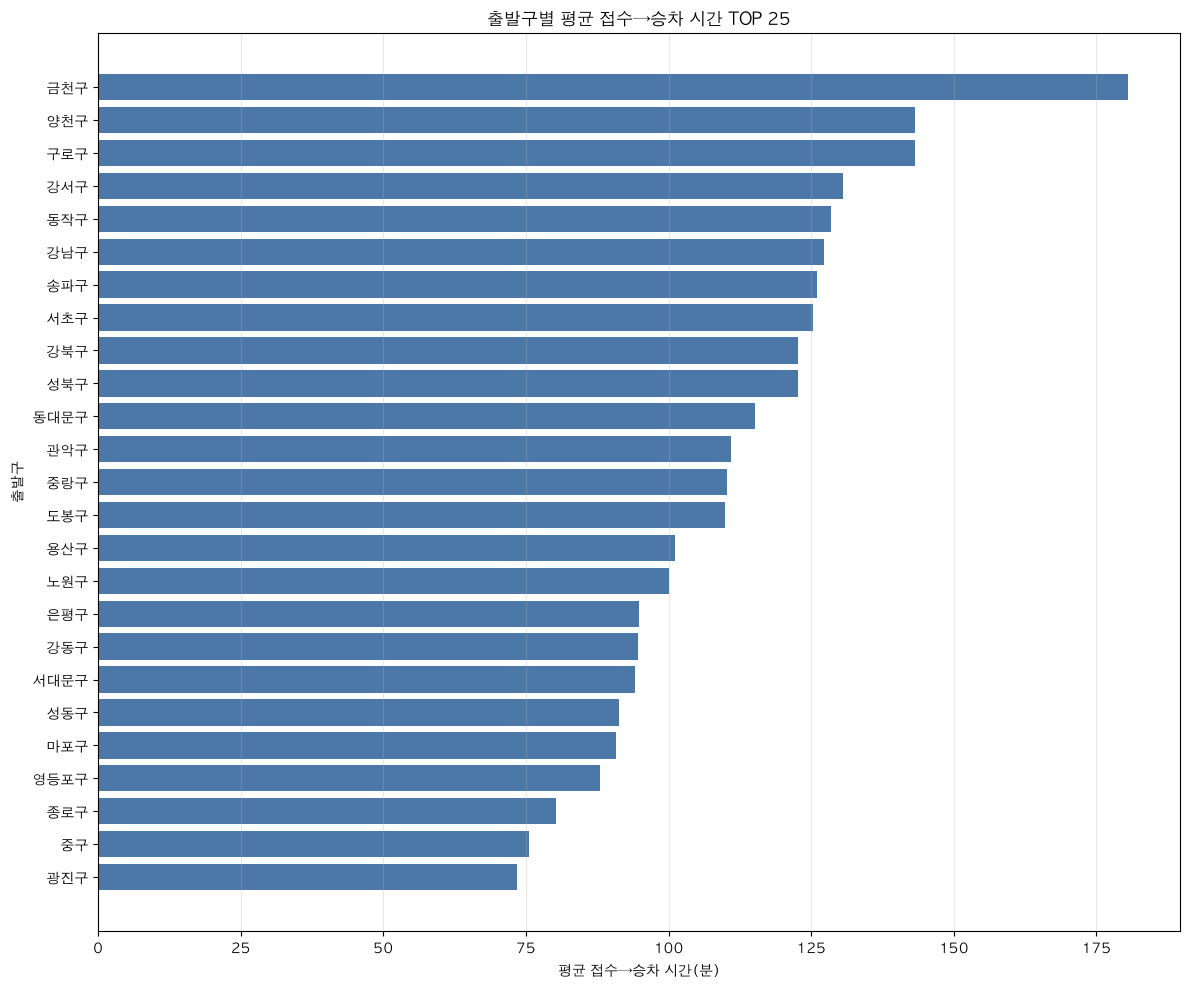

In [6]:
region_wait_summary = (
    df_wait_valid
    .dropna(subset=['출발구'])
    .groupby('출발구')
    .agg(
        접수건수=('접수일시', 'size'),
        탑승건수=('탑승여부', 'sum'),
        취소건수=('취소여부', 'sum'),
        평균_접수승차분=('접수_승차_분', 'mean'),
        중앙값_접수승차분=('접수_승차_분', 'median'),
        p90_접수승차분=('접수_승차_분', lambda s: s.quantile(0.9)),
    )
    .reset_index()
)
region_wait_summary['취소율(%)'] = region_wait_summary['취소건수'] / region_wait_summary['접수건수'] * 100
region_wait_summary['탑승전환율(%)'] = region_wait_summary['탑승건수'] / region_wait_summary['접수건수'] * 100
region_wait_summary = region_wait_summary.sort_values(['접수건수', '평균_접수승차분'], ascending=[False, False]).reset_index(drop=True)

high_demand_threshold = region_wait_summary['접수건수'].quantile(0.75)
region_bottleneck_candidates = (
    region_wait_summary[region_wait_summary['접수건수'] >= high_demand_threshold]
    .sort_values('평균_접수승차분', ascending=False)
    .reset_index(drop=True)
)

display(region_wait_summary.head(25))
display(region_bottleneck_candidates.head(15))

plot_data = region_wait_summary.head(25).sort_values('평균_접수승차분')
plt.figure(figsize=(12, 10))
plt.barh(plot_data['출발구'], plot_data['평균_접수승차분'], color='#4c78a8')
plt.title('출발구별 평균 접수→승차 시간 TOP 25')
plt.xlabel('평균 접수→승차 시간(분)')
plt.ylabel('출발구')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 취소까지 걸린 시간 분석


,접수시간대,취소건수,평균_접수취소분,중앙값_접수취소분,p90_접수취소분
0,00시,500,16.359689,8.291667,38.151733
1,01시,305,18.342981,7.847667,46.305483
2,02시,297,52.217096,28.098383,125.177400
3,03시,888,110.703191,123.167858,156.822685
4,04시,4185,101.448722,116.710617,153.059857
5,05시,6229,90.091135,102.641950,153.502957
6,06시,5858,59.499134,48.194525,138.739617
7,07시,19624,144.333767,16.629333,181.595698
8,08시,20807,127.912418,18.562000,132.602423
9,09시,16777,35.316470,12.208117,70.641733


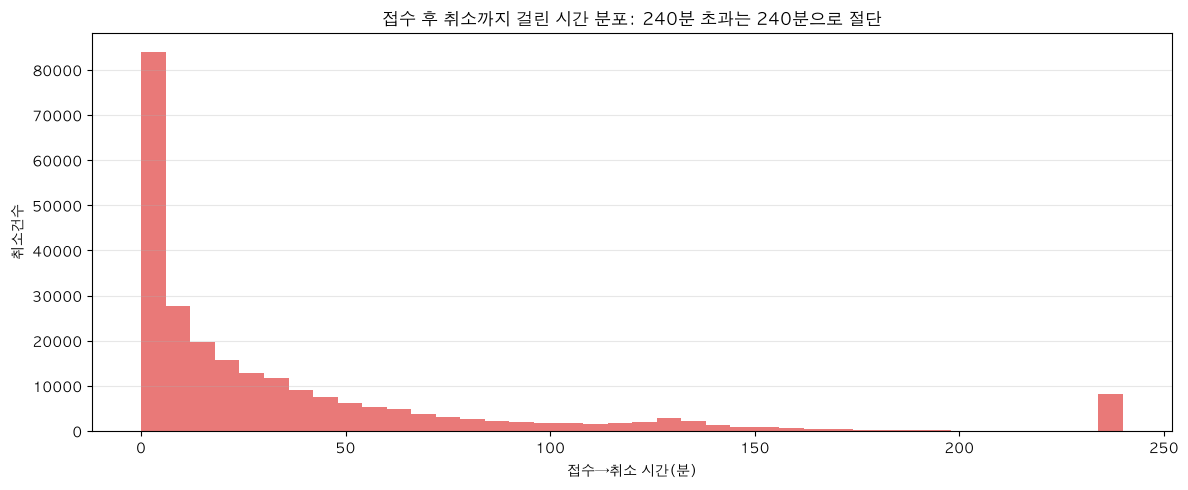

,접수시간대,취소건수,평균_접수취소분,중앙값_접수취소분,p90_접수취소분
5,05시,6229,90.091135,102.641950,153.502957
16,16시,23462,35.769625,19.312692,71.849440
17,17시,14077,37.443599,15.074717,69.890917
20,20시,5027,39.973939,17.584000,70.122967
21,21시,3180,48.565978,18.398358,76.051667
22,22시,1543,46.991637,13.233333,77.277127


In [ ]:
cancel_elapsed_summary = (
    df_wait_valid[df_wait_valid['취소여부']]
    .dropna(subset=['접수_취소_분'])
    .groupby('접수시간대_label')
    .agg(
        취소건수=('접수_취소_분', 'size'),
        평균_접수취소분=('접수_취소_분', 'mean'),
        중앙값_접수취소분=('접수_취소_분', 'median'),
        p90_접수취소분=('접수_취소_분', lambda s: s.quantile(0.9)),
    )
    .reindex([f'{hour:02d}시' for hour in range(24)])
    .reset_index(names='접수시간대')
)

display(cancel_elapsed_summary)

plt.figure(figsize=(12, 5))
plt.hist(
    df_wait_valid.loc[df_wait_valid['취소여부'], '접수_취소_분'].dropna().clip(upper=240),
    bins=40,
    color='#e45756',
    alpha=0.8
)
plt.title('접수 후 취소까지 걸린 시간 분포: 240분 초과는 240분으로 절단')
plt.xlabel('접수→취소 시간(분)')
plt.ylabel('취소건수')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

focus_hours = ['05시', '16시', '17시', '20시', '21시', '22시']
display(cancel_elapsed_summary[cancel_elapsed_summary['접수시간대'].isin(focus_hours)])
